# 05 - Validación del Modelo
Evaluación exhaustiva del modelo seleccionado sobre el conjunto de test.

In [1]:

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)

# Cargar datos y modelo
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()
model   = joblib.load('../models/best_model.pkl')

y_pred      = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Modelo cargado y predicciones generadas.")


Modelo cargado y predicciones generadas.


In [2]:

# ── 1. Métricas principales ────────────────────────────────────────────────
f1  = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("MÉTRICAS DE EVALUACIÓN - CONJUNTO DE TEST")
print("=" * 50)
print(f"F1-Score (target=1):  {f1:.4f}  ← MÉTRICA PRINCIPAL")
print(f"ROC-AUC:              {roc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No fumador (0)','Fumador (1)']))


MÉTRICAS DE EVALUACIÓN - CONJUNTO DE TEST
F1-Score (target=1):  0.7322  ← MÉTRICA PRINCIPAL
ROC-AUC:              0.8641

                precision    recall  f1-score   support

No fumador (0)       0.90      0.72      0.80      6334
   Fumador (1)       0.64      0.86      0.73      3666

      accuracy                           0.77     10000
     macro avg       0.77      0.79      0.76     10000
  weighted avg       0.80      0.77      0.77     10000



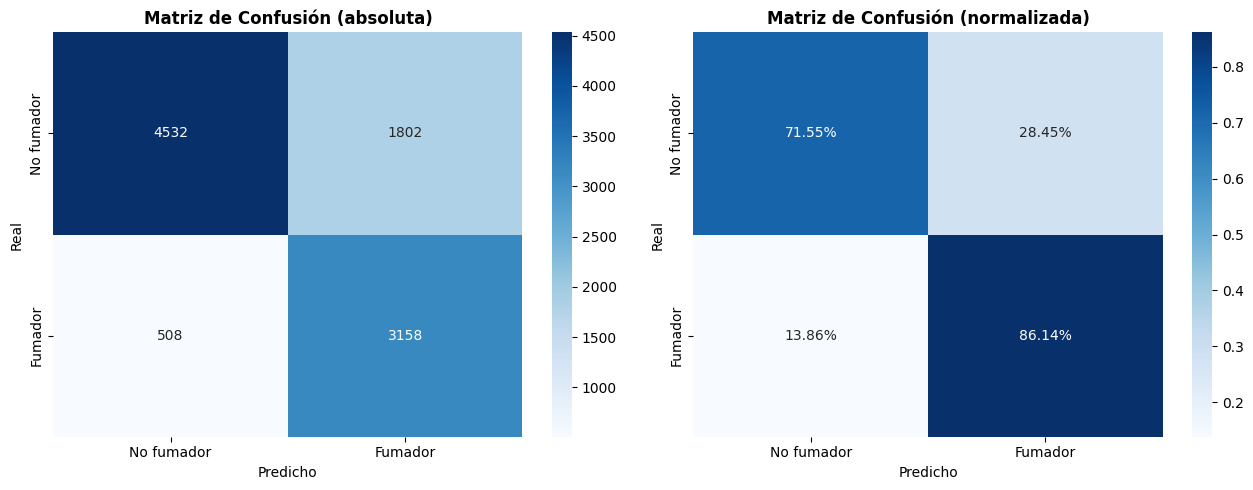

TP=3158, FP=1802, TN=4532, FN=508


In [3]:

# ── 2. Matriz de confusión ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusión absoluta
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No fumador','Fumador'],
            yticklabels=['No fumador','Fumador'])
axes[0].set_title('Matriz de Confusión (absoluta)', fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predicho')

# Confusión normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['No fumador','Fumador'],
            yticklabels=['No fumador','Fumador'])
axes[1].set_title('Matriz de Confusión (normalizada)', fontweight='bold')
axes[1].set_ylabel('Real'); axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('../data/processed/val_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP={tp}, FP={fp}, TN={tn}, FN={fn}")


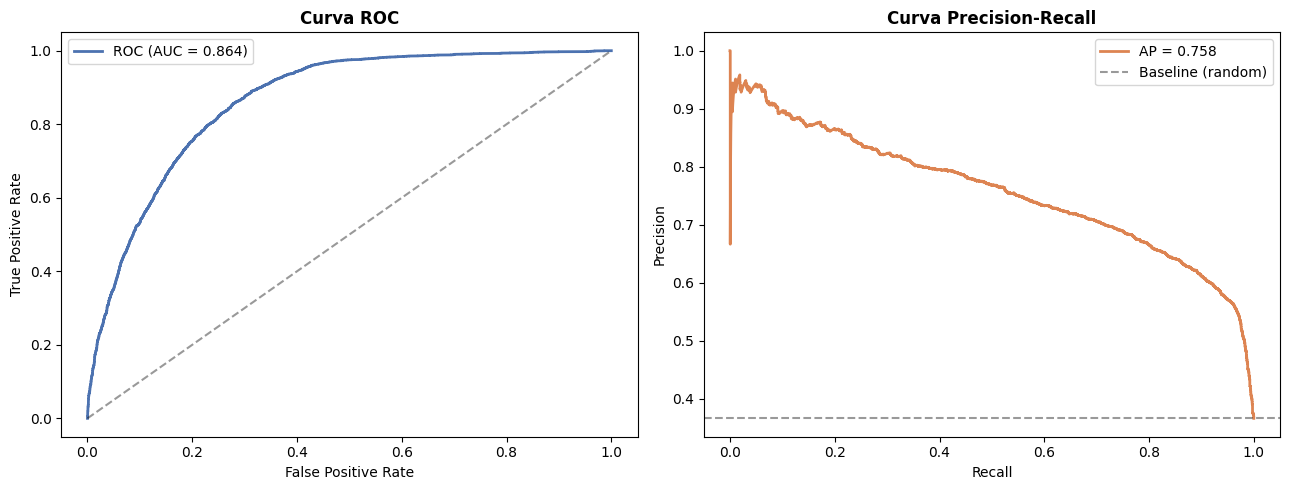

In [4]:

# ── 3. Curva ROC ──────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'ROC (AUC = {roc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].legend()

# Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)
axes[1].plot(rec, prec, color='#DD8452', lw=2, label=f'AP = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4, label='Baseline (random)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/val_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


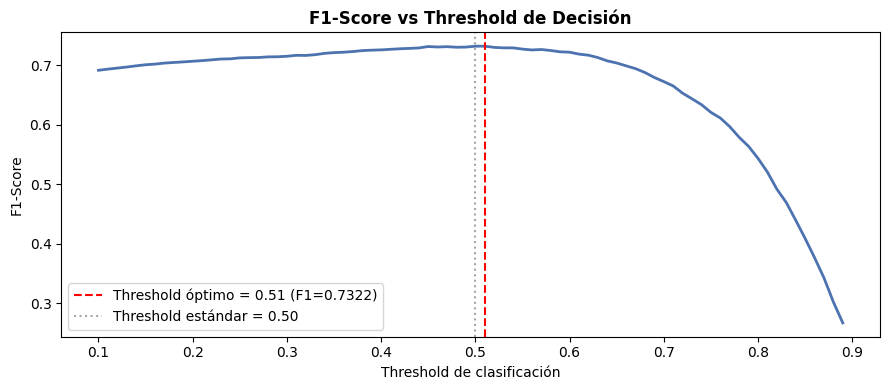

Threshold estándar (0.5) → F1 = 0.7322
Threshold óptimo  (0.51) → F1 = 0.7322

Threshold óptimo guardado: 0.5100


In [5]:

# ── 4. Análisis de threshold ───────────────────────────────────────────────
from sklearn.metrics import f1_score as f1s

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1s(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]

best_t  = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, color='#4C72B0', lw=2)
ax.axvline(best_t, color='red', linestyle='--', label=f'Threshold óptimo = {best_t:.2f} (F1={best_f1:.4f})')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Threshold estándar = 0.50')
ax.set_xlabel('Threshold de clasificación')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score vs Threshold de Decisión', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/val_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Threshold estándar (0.5) → F1 = {f1s(y_test, (y_pred_proba>=0.5).astype(int)):.4f}")
print(f"Threshold óptimo  ({best_t:.2f}) → F1 = {best_f1:.4f}")
joblib.dump(best_t, '../models/best_threshold.pkl')
print(f"\nThreshold óptimo guardado: {best_t:.4f}")


In [6]:

# ── 5. Resumen final ──────────────────────────────────────────────────────
print("=" * 60)
print("RESUMEN DE VALIDACIÓN")
print("=" * 60)
print(f"F1-Score  (threshold=0.5):       {f1:.4f}")
print(f"F1-Score  (threshold óptimo):    {best_f1:.4f}")
print(f"ROC-AUC:                         {roc:.4f}")
print(f"Average Precision:               {ap:.4f}")
print(f"Threshold óptimo seleccionado:   {best_t:.4f}")


RESUMEN DE VALIDACIÓN
F1-Score  (threshold=0.5):       0.7322
F1-Score  (threshold óptimo):    0.7322
ROC-AUC:                         0.8641
Average Precision:               0.7584
Threshold óptimo seleccionado:   0.5100
